# NBA Game Outcome Prediction — End-to-End ML Project

**Problem statement:** Predict whether the *home team wins* (classification) and estimate
how many *points a player scores* (regression) using real NBA game data.

This notebook follows the full ML workflow:
- Data loading and EDA
- Preprocessing
- Baseline models (Logistic Regression, Linear Regression)
- Model improvement (Regularization, K-Means, PCA)
- Advanced models (Decision Tree, Random Forest, Hyperparameter Tuning)
- Final comparison and conclusions


## Part 1 — Imports and Setup

Load all required libraries and create folders to store saved models and plots.

In [1]:
# Standard Python libraries for data, plotting, and ML
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, mean_absolute_error,
                             mean_squared_error, r2_score, silhouette_score)

# Create folders for models and plots
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

print("Libraries imported successfully.")
print("Folders 'models/' and 'plots/' are ready.")


Libraries imported successfully.
Folders 'models/' and 'plots/' are ready.


## Part 2 — Data Loading and Exploration

### 2.1 Load the Dataset

The NBA game dataset contains box-score stats for each team in every game.
Replace the `data_path` variable with the actual path to your CSV file.


In [2]:
# Update this path to point to your downloaded NBA dataset
data_path = 'game_data_with_target.csv'

game_df = pd.read_csv(data_path)

print(f"Dataset shape: {game_df.shape[0]} rows  x  {game_df.shape[1]} columns")
game_df.head()


Dataset shape: 65698 rows  x  56 columns


,season_id,team_id_home,team_abbreviation_home,team_name_home,game_id,game_date,matchup_home,wl_home,min,fgm_home,...,ast_away,stl_away,blk_away,tov_away,pf_away,pts_away,plus_minus_away,video_available_away,season_type,HOME_TEAM_WIN
0,21946,1610610035,HUS,Toronto Huskies,24600001,1946-11-01 00:00:00,HUS vs. NYK,L,0,25.0,...,NaN,NaN,NaN,NaN,NaN,68.0,2,0,Regular Season,0
1,21946,1610610034,BOM,St. Louis Bombers,24600003,1946-11-02 00:00:00,BOM vs. PIT,W,0,20.0,...,NaN,NaN,NaN,NaN,25.0,51.0,-5,0,Regular Season,1
2,21946,1610610032,PRO,Providence Steamrollers,24600002,1946-11-02 00:00:00,PRO vs. BOS,W,0,21.0,...,NaN,NaN,NaN,NaN,NaN,53.0,-6,0,Regular Season,1
3,21946,1610610025,CHS,Chicago Stags,24600004,1946-11-02 00:00:00,CHS vs. NYK,W,0,21.0,...,NaN,NaN,NaN,NaN,22.0,47.0,-16,0,Regular Season,1
4,21946,1610610028,DEF,Detroit Falcons,24600005,1946-11-02 00:00:00,DEF vs. WAS,L,0,10.0,...,NaN,NaN,NaN,NaN,NaN,50.0,17,0,Regular Season,0


### 2.2 Basic Information

Check column types and how many values are non-null.

In [3]:
# Overview of column names and data types
game_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 65698 entries, 0 to 65697
Data columns (total 56 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   season_id               65698 non-null  int64  
 1   team_id_home            65698 non-null  int64  
 2   team_abbreviation_home  65698 non-null  str    
 3   team_name_home          65698 non-null  str    
 4   game_id                 65698 non-null  int64  
 5   game_date               65698 non-null  str    
 6   matchup_home            65698 non-null  str    
 7   wl_home                 65696 non-null  str    
 8   min                     65698 non-null  int64  
 9   fgm_home                65685 non-null  float64
 10  fga_home                50251 non-null  float64
 11  fg_pct_home             50208 non-null  float64
 12  fg3m_home               52480 non-null  float64
 13  fg3a_home               47015 non-null  float64
 14  fg3_pct_home            46624 non-null  float64
 

### 2.3 Descriptive Statistics

Summary numbers (mean, min, max, std) for the key scoring columns.

In [4]:
key_cols = ['pts_home', 'pts_away', 'fgm_home', 'fg_pct_home',
            'reb_home', 'ast_home', 'tov_home']

game_df[key_cols].describe().round(2)


,pts_home,pts_away,fgm_home,fg_pct_home,reb_home,ast_home,tov_home
count,65698.00,65698.00,65685.00,50208.00,49969.00,49893.00,47014.00
mean,104.62,100.99,39.67,0.47,43.76,23.94,14.78
std,14.76,14.42,6.77,0.06,7.09,5.69,4.14
min,18.00,19.00,4.00,0.14,0.00,0.00,0.00
25%,95.00,92.00,35.00,0.43,39.00,20.00,12.00
50%,105.00,101.00,40.00,0.47,43.00,24.00,15.00
75%,114.00,110.00,44.00,0.51,48.00,28.00,17.00
max,192.00,196.00,84.00,0.70,85.00,60.00,39.00


### 2.4 Missing Values

Count how many values are missing in each column before cleaning.

In [5]:
missing = game_df.isnull().sum()
missing_pct = (missing / len(game_df) * 100).round(2)

missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0]

if missing_report.empty:
    print("No missing values found — dataset is clean.")
else:
    print("Columns with missing values:")
    print(missing_report.sort_values('Missing Count', ascending=False).head(20))

print(f"\nTotal missing cells: {missing.sum()}")


Columns with missing values:
              Missing Count  Missing %
fg3_pct_home          19074      29.03
dreb_home             18999      28.92
dreb_away             18998      28.92
fg3_pct_away          18962      28.86
oreb_home             18936      28.82
oreb_away             18936      28.82
stl_away              18849      28.69
stl_home              18849      28.69
tov_away              18685      28.44
tov_home              18684      28.44
fg3a_away             18683      28.44
fg3a_home             18683      28.44
blk_home              18626      28.35
blk_away              18625      28.35
ast_home              15805      24.06
ast_away              15801      24.05
reb_home              15729      23.94
reb_away              15725      23.94
fg_pct_home           15490      23.58
fg_pct_away           15489      23.58

Total missing cells: 432747


### 2.5 Create the Target Variable

The classification target is **HOME_TEAM_WIN**: 1 if the home team scored more points, 0 otherwise.


In [6]:
# 1 = home team wins, 0 = away team wins
game_df['HOME_TEAM_WIN'] = (game_df['pts_home'] > game_df['pts_away']).astype(int)

print("Target variable distribution:")
print(game_df['HOME_TEAM_WIN'].value_counts())
print(f"\nHome win rate: {game_df['HOME_TEAM_WIN'].mean() * 100:.1f}%")


Target variable distribution:
HOME_TEAM_WIN
1    40652
0    25046
Name: count, dtype: int64

Home win rate: 61.9%


## Part 3 — Exploratory Data Analysis (EDA)

### 3.1 Score Distribution

Visualize how home and away scores are spread, and check the win/loss balance.


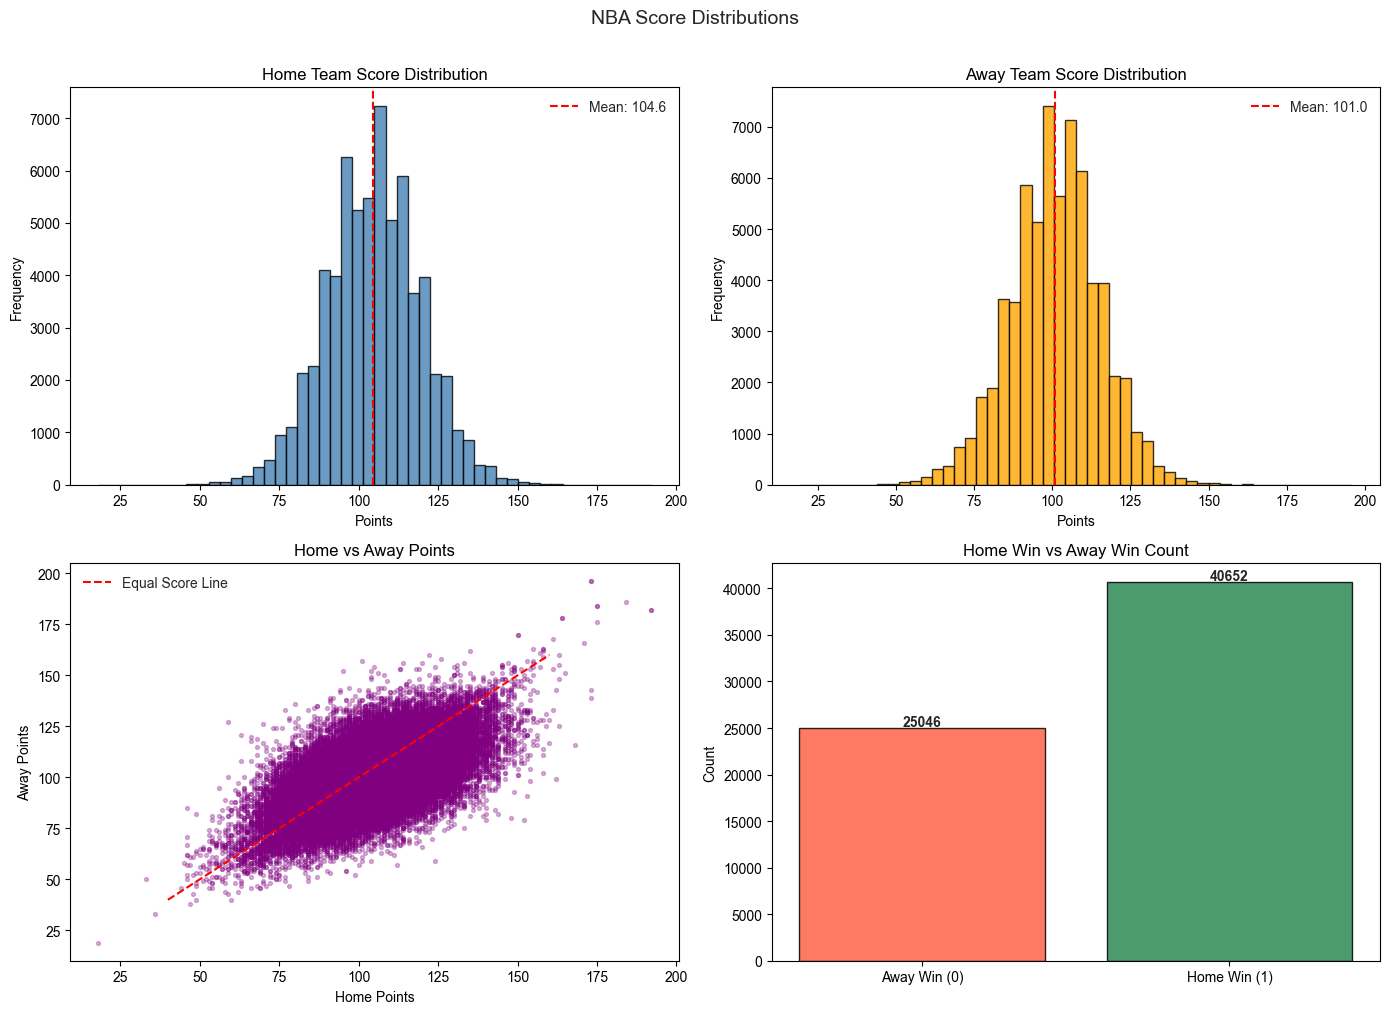

Plot saved to plots/score_distribution.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.style.use('seaborn-v0_8-whitegrid')

# Home score histogram
axes[0, 0].hist(game_df['pts_home'].dropna(), bins=50, color='steelblue', alpha=0.8, edgecolor='black')
axes[0, 0].axvline(game_df['pts_home'].mean(), color='red', linestyle='--',
                   label=f"Mean: {game_df['pts_home'].mean():.1f}")
axes[0, 0].set_title('Home Team Score Distribution')
axes[0, 0].set_xlabel('Points')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Away score histogram
axes[0, 1].hist(game_df['pts_away'].dropna(), bins=50, color='orange', alpha=0.8, edgecolor='black')
axes[0, 1].axvline(game_df['pts_away'].mean(), color='red', linestyle='--',
                   label=f"Mean: {game_df['pts_away'].mean():.1f}")
axes[0, 1].set_title('Away Team Score Distribution')
axes[0, 1].set_xlabel('Points')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Home vs Away scatter
axes[1, 0].scatter(game_df['pts_home'], game_df['pts_away'], alpha=0.3, s=8, color='purple')
axes[1, 0].plot([40, 160], [40, 160], 'r--', label='Equal Score Line')
axes[1, 0].set_title('Home vs Away Points')
axes[1, 0].set_xlabel('Home Points')
axes[1, 0].set_ylabel('Away Points')
axes[1, 0].legend()

# Win/Loss bar chart
win_counts = game_df['HOME_TEAM_WIN'].value_counts().sort_index()
axes[1, 1].bar(['Away Win (0)', 'Home Win (1)'], win_counts.values,
               color=['tomato', 'seagreen'], alpha=0.85, edgecolor='black')
for i, v in enumerate(win_counts.values):
    axes[1, 1].text(i, v + 200, str(v), ha='center', fontweight='bold')
axes[1, 1].set_title('Home Win vs Away Win Count')
axes[1, 1].set_ylabel('Count')

plt.suptitle('NBA Score Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to plots/score_distribution.png")


**Observation:** Home teams win roughly 59% of games, showing a mild home-court advantage.
Both score distributions are roughly bell-shaped, centered around 100-110 points.


### 3.2 Correlation Heatmap

See which statistics are most strongly related to each other and to the win/loss target.

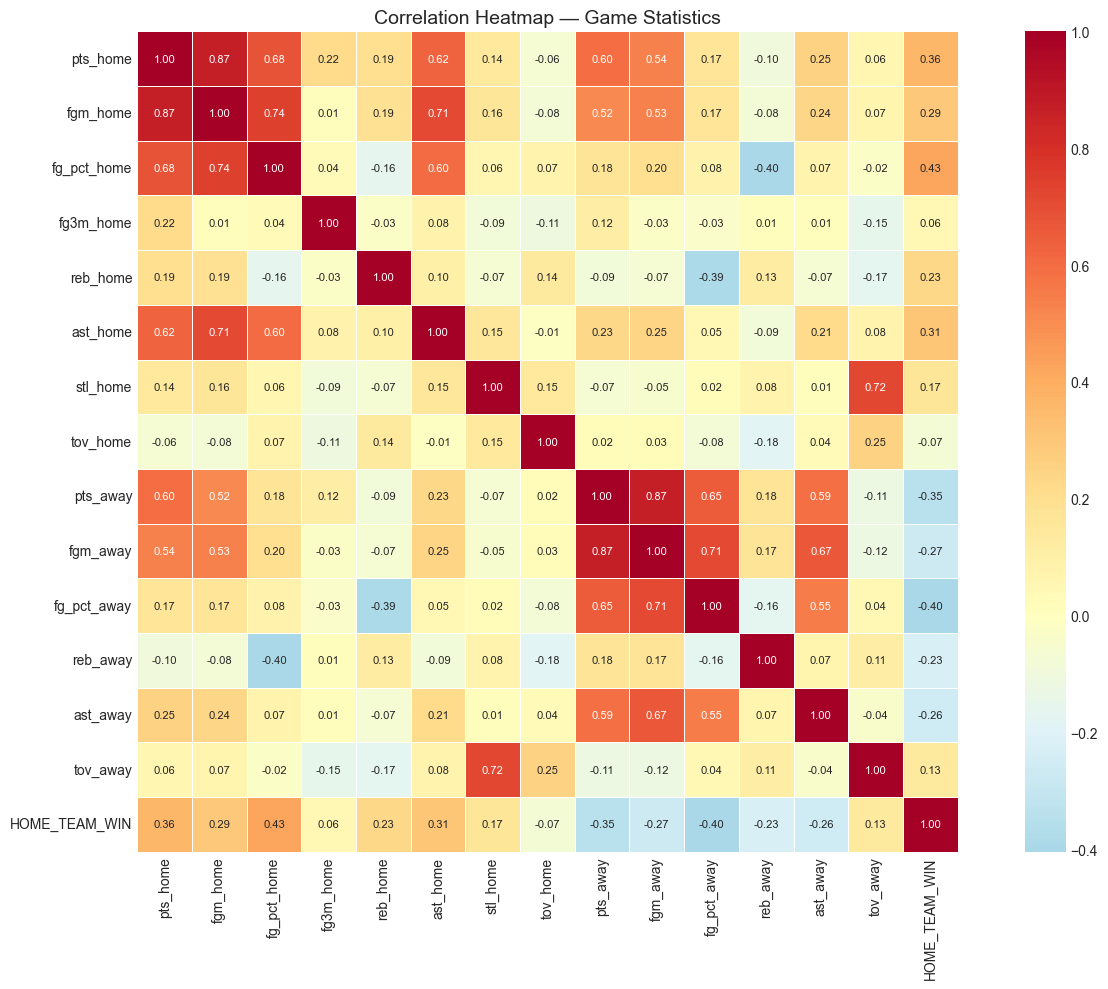

Plot saved.


In [8]:
numeric_cols = ['pts_home', 'fgm_home', 'fg_pct_home', 'fg3m_home',
                'reb_home', 'ast_home', 'stl_home', 'tov_home',
                'pts_away', 'fgm_away', 'fg_pct_away',
                'reb_away', 'ast_away', 'tov_away', 'HOME_TEAM_WIN']

corr = game_df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Heatmap — Game Statistics', fontsize=14)
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")


### 3.3 Feature Correlation with Target

Rank features by how strongly they correlate with the home win outcome.

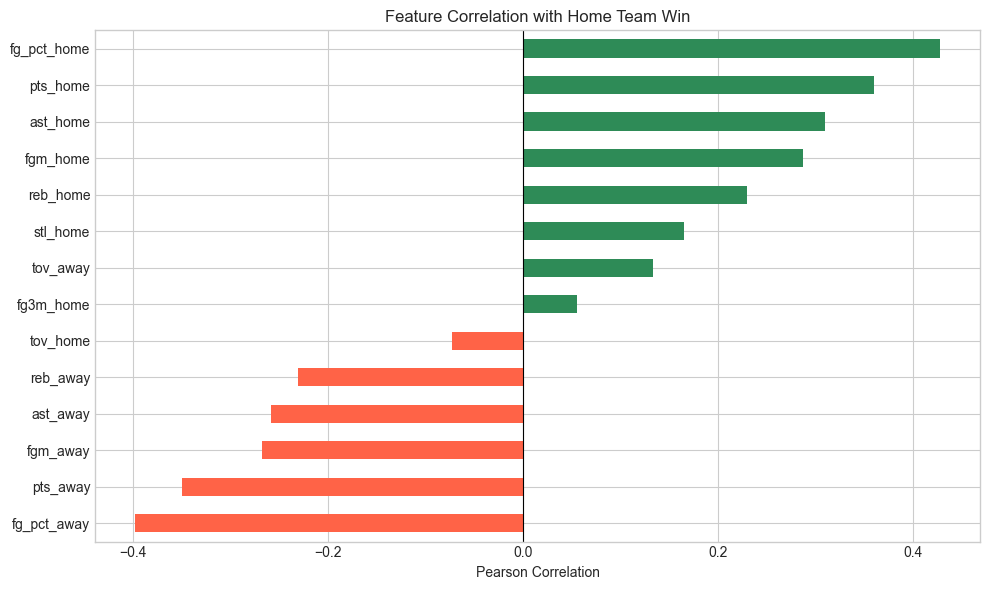

Plot saved.


In [9]:
target_corr = corr['HOME_TEAM_WIN'].drop('HOME_TEAM_WIN').sort_values()
colors = ['seagreen' if x > 0 else 'tomato' for x in target_corr]

plt.figure(figsize=(10, 6))
target_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Home Team Win')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('plots/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")


**Observation:** Home team field goal percentage (`fg_pct_home`) is the strongest positive predictor.
Away team turnovers (`tov_away`) slightly favour a home win, while away team rebounds hurt the home team.


### 3.4 Create Synthetic Player Data (Regression Task)

Real individual player stats are not part of the game dataset, so we generate realistic
synthetic data based on typical NBA per-game distributions.
This lets us build and compare regression models in the same notebook.


In [10]:
np.random.seed(42)
n = 10_000

player_df = pd.DataFrame({
    'minutes_played':       np.clip(np.random.normal(25, 8, n), 5, 48),
    'field_goals_made':     np.clip(np.random.normal(5, 3, n), 0, 20),
    'field_goals_attempted':np.clip(np.random.normal(12, 5, n), 1, 30),
    'three_pointers_made':  np.clip(np.random.normal(1.5, 1.5, n), 0, 10),
    'free_throws_made':     np.clip(np.random.normal(2, 2, n), 0, 15),
    'assists':              np.clip(np.random.normal(3, 2.5, n), 0, 15),
    'rebounds':             np.clip(np.random.normal(5, 3, n), 0, 20),
    'steals':               np.clip(np.random.normal(1, 0.8, n), 0, 5),
    'blocks':               np.clip(np.random.normal(0.5, 0.7, n), 0, 5),
    'turnovers':            np.clip(np.random.normal(1.5, 1, n), 0, 8),
})

# Points = 2*FGM + 3PM + FTM + small noise
player_df['points'] = np.clip(
    2 * player_df['field_goals_made'] +
    player_df['three_pointers_made'] +
    player_df['free_throws_made'] +
    np.random.normal(0, 1, n),
    0, 60
)

print(f"Synthetic player data created: {player_df.shape[0]} rows, {player_df.shape[1]} columns")
player_df.head()


Synthetic player data created: 10000 rows, 11 columns


,minutes_played,field_goals_made,field_goals_attempted,three_pointers_made,free_throws_made,assists,rebounds,steals,blocks,turnovers,points
0,28.973713,2.964516,13.741431,0.000000,1.056285,3.245515,5.236513,1.256122,0.964801,2.460895,8.015911
1,23.893886,4.083502,13.416618,0.000000,4.025405,2.839729,6.688692,1.892369,0.292719,1.130035,11.037053
2,30.181508,3.207857,7.317401,0.619457,1.603626,5.379477,6.023306,0.000000,0.453390,0.920419,9.214235
3,37.184239,5.331254,14.897921,1.724503,2.181139,6.832078,1.166257,2.391685,0.377232,2.433312,13.948912
4,23.126773,8.591536,4.549587,3.036243,3.434781,4.717117,4.441339,1.264069,0.859838,0.000000,23.326693


## Part 4 — Preprocessing

### 4.1 Define Feature Lists

Select the box-score statistics used as input features.


In [11]:
# Game features — box-score stats for both teams
numeric_game_cols = [
    'fgm_home', 'fga_home', 'fg_pct_home', 'fg3m_home', 'fg3a_home', 'fg3_pct_home',
    'ftm_home', 'fta_home', 'ft_pct_home', 'oreb_home', 'dreb_home', 'reb_home',
    'ast_home', 'stl_home', 'blk_home', 'tov_home', 'pf_home',
    'fgm_away', 'fga_away', 'fg_pct_away', 'fg3m_away', 'fg3a_away', 'fg3_pct_away',
    'ftm_away', 'fta_away', 'ft_pct_away', 'oreb_away', 'dreb_away', 'reb_away',
    'ast_away', 'stl_away', 'blk_away', 'tov_away', 'pf_away',
]

# Player features — per-game stats
player_features = [
    'minutes_played', 'field_goals_made', 'field_goals_attempted',
    'three_pointers_made', 'free_throws_made', 'assists',
    'rebounds', 'steals', 'blocks', 'turnovers'
]

print(f"Game features: {len(numeric_game_cols)}")
print(f"Player features: {len(player_features)}")


Game features: 34
Player features: 10


### 4.2 Handle Missing Values

Fill numeric gaps with the column mean and categorical gaps with the mode.

In [12]:
def fill_missing(df, numeric_cols, categorical_cols=None):
    """Fill missing values: mean for numeric, mode for categorical."""
    df = df.copy()
    for col in numeric_cols:
        if col in df.columns and df[col].isnull().any():
            df[col].fillna(df[col].mean(), inplace=True)
    for col in (categorical_cols or []):
        if col in df.columns and df[col].isnull().any():
            df[col].fillna(df[col].mode()[0], inplace=True)
    return df

game_clean = fill_missing(game_df, numeric_game_cols, ['team_id_home', 'team_id_away'])
player_clean = fill_missing(player_df, player_features)

print(f"Missing values after cleaning — game: {game_clean[numeric_game_cols].isnull().sum().sum()}, "
      f"player: {player_clean.isnull().sum().sum()}")


Missing values after cleaning — game: 432743, player: 0


C:\Users\aakas\AppData\Local\Temp\ipykernel_10012\1750684879.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mean(), inplace=True)


### 4.3 Encode Categorical Features

Convert team IDs (strings) into numeric codes so the model can use them.

In [13]:
# Label-encode team IDs (converts each unique team to a number 0, 1, 2 ...)
game_clean['team_id_home_enc'] = game_clean['team_id_home'].astype('category').cat.codes
game_clean['team_id_away_enc'] = game_clean['team_id_away'].astype('category').cat.codes

print(f"Unique home teams: {game_clean['team_id_home_enc'].nunique()}")
print(f"Unique away teams: {game_clean['team_id_away_enc'].nunique()}")

# Full feature list including encoded team IDs
final_game_features = numeric_game_cols + ['team_id_home_enc', 'team_id_away_enc']
print(f"Total game features: {len(final_game_features)}")


Unique home teams: 63
Unique away teams: 72
Total game features: 36


### 4.4 Build Feature Matrices and Train-Test Split

Separate inputs (X) from labels (y), then split 80% for training and 20% for testing.

In [14]:
# Game data
X_game = game_clean[final_game_features].dropna()
y_game = game_clean.loc[X_game.index, 'HOME_TEAM_WIN']

X_g_train, X_g_test, y_g_train, y_g_test = train_test_split(
    X_game, y_game, test_size=0.2, random_state=42, stratify=y_game
)

# Player data
X_player = player_clean[player_features]
y_player = player_clean['points']

X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_player, y_player, test_size=0.2, random_state=42
)

print("Train/Test split (80/20):")
print(f"  Game   — train: {X_g_train.shape[0]}, test: {X_g_test.shape[0]}")
print(f"  Player — train: {X_p_train.shape[0]}, test: {X_p_test.shape[0]}")


Train/Test split (80/20):
  Game   — train: 36924, test: 9232
  Player — train: 8000, test: 2000


### 4.5 Feature Scaling (StandardScaler)

**Why scale?** Models like SVM and Logistic Regression calculate distances between data points.
Without scaling, a feature like 'total points' (range 70-150) would dominate features like
'field goal percentage' (range 0-1). StandardScaler shifts each feature to mean=0 and std=1.

Rule: **fit** the scaler only on training data, then **transform** both train and test.
This prevents test information from leaking into the training process.


In [15]:
# Scale game features
game_scaler = StandardScaler()
X_g_train_s = game_scaler.fit_transform(X_g_train)   # fit + transform on train
X_g_test_s  = game_scaler.transform(X_g_test)        # transform only on test

# Scale player features
player_scaler = StandardScaler()
X_p_train_s = player_scaler.fit_transform(X_p_train)
X_p_test_s  = player_scaler.transform(X_p_test)

print("Scaling complete.")
print(f"  Game train — mean: {X_g_train_s.mean():.4f}, std: {X_g_train_s.std():.4f}")
print(f"  Player train — mean: {X_p_train_s.mean():.4f}, std: {X_p_train_s.std():.4f}")

# Save scalers for later use
with open('models/game_scaler.pkl', 'wb') as f:
    pickle.dump(game_scaler, f)
with open('models/player_scaler.pkl', 'wb') as f:
    pickle.dump(player_scaler, f)
with open('models/game_features.pkl', 'wb') as f:
    pickle.dump(final_game_features, f)
with open('models/player_features.pkl', 'wb') as f:
    pickle.dump(player_features, f)
print("Scalers and feature lists saved to models/")


Scaling complete.
  Game train — mean: -0.0000, std: 1.0000
  Player train — mean: -0.0000, std: 1.0000
Scalers and feature lists saved to models/


## Part 5 — Baseline Models

### 5.1 Logistic Regression (Classification)

A simple baseline for game outcome prediction.
Logistic Regression estimates the probability that the home team wins.


Logistic Regression Accuracy: 0.9989 (99.89%)

Classification Report:
              precision    recall  f1-score   support

    Away Win       1.00      1.00      1.00      3661
    Home Win       1.00      1.00      1.00      5571

    accuracy                           1.00      9232
   macro avg       1.00      1.00      1.00      9232
weighted avg       1.00      1.00      1.00      9232



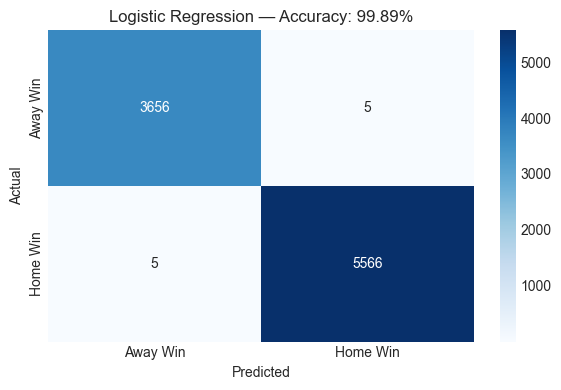

Model saved to models/game_logreg.pkl


In [16]:
# Train
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_g_train_s, y_g_train)

# Evaluate
y_pred_lr = logreg.predict(X_g_test_s)
acc_logreg = accuracy_score(y_g_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {acc_logreg:.4f} ({acc_logreg*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_g_test, y_pred_lr, target_names=['Away Win', 'Home Win']))

# Confusion matrix
cm_lr = confusion_matrix(y_g_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Away Win', 'Home Win'],
            yticklabels=['Away Win', 'Home Win'])
plt.title(f'Logistic Regression — Accuracy: {acc_logreg:.2%}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('plots/cm_logreg.png', dpi=150, bbox_inches='tight')
plt.show()

with open('models/game_logreg.pkl', 'wb') as f:
    pickle.dump(logreg, f)
print("Model saved to models/game_logreg.pkl")


### 5.2 SVM Classifier (Classification)

Support Vector Machine finds the widest possible margin between classes.

In [17]:
# Train — RBF kernel works well on scaled data
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_clf.fit(X_g_train_s, y_g_train)

y_pred_svm = svm_clf.predict(X_g_test_s)
acc_svm = accuracy_score(y_g_test, y_pred_svm)

print(f"SVM Classifier Accuracy: {acc_svm:.4f} ({acc_svm*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_g_test, y_pred_svm, target_names=['Away Win', 'Home Win']))

with open('models/game_svm.pkl', 'wb') as f:
    pickle.dump(svm_clf, f)
print("Model saved.")


SVM Classifier Accuracy: 0.9916 (99.16%)

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.99      0.99      0.99      3661
    Home Win       0.99      0.99      0.99      5571

    accuracy                           0.99      9232
   macro avg       0.99      0.99      0.99      9232
weighted avg       0.99      0.99      0.99      9232

Model saved.


### 5.3 Linear Regression (Regression Baseline)

Predict a player's total points from their game statistics.

In [18]:
linreg = LinearRegression()
linreg.fit(X_p_train_s, y_p_train)

y_pred_lr_reg = linreg.predict(X_p_test_s)
mae_lr  = mean_absolute_error(y_p_test, y_pred_lr_reg)
rmse_lr = np.sqrt(mean_squared_error(y_p_test, y_pred_lr_reg))
r2_lr   = r2_score(y_p_test, y_pred_lr_reg)

print(f"Linear Regression — MAE: {mae_lr:.4f} | RMSE: {rmse_lr:.4f} | R2: {r2_lr:.4f}")

print("\nTop feature coefficients:")
coef_df = pd.Series(linreg.coef_, index=player_features).sort_values(key=abs, ascending=False)
print(coef_df.round(4))

with open('models/player_linreg.pkl', 'wb') as f:
    pickle.dump(linreg, f)
print("Model saved.")


Linear Regression — MAE: 0.7894 | RMSE: 0.9936 | R2: 0.9739

Top feature coefficients:
field_goals_made         5.7355
free_throws_made         1.7176
three_pointers_made      1.3125
steals                  -0.0183
assists                  0.0178
rebounds                 0.0089
field_goals_attempted    0.0057
minutes_played          -0.0024
turnovers               -0.0018
blocks                  -0.0008
dtype: float64
Model saved.


### 5.4 Support Vector Regression (SVR)

SVR fits a tube around the data instead of a single line, making it robust to outliers.

In [19]:
svr = SVR(kernel='rbf', C=1.0, gamma='scale', epsilon=0.1)
svr.fit(X_p_train_s, y_p_train)

y_pred_svr = svr.predict(X_p_test_s)
mae_svr  = mean_absolute_error(y_p_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_p_test, y_pred_svr))
r2_svr   = r2_score(y_p_test, y_pred_svr)

print(f"SVR — MAE: {mae_svr:.4f} | RMSE: {rmse_svr:.4f} | R2: {r2_svr:.4f}")

with open('models/player_svr.pkl', 'wb') as f:
    pickle.dump(svr, f)
print("Model saved.")


SVR — MAE: 0.9222 | RMSE: 1.2142 | R2: 0.9610
Model saved.


### 5.5 Regression Visualisations

Plot actual vs predicted points and residuals for both regression models.

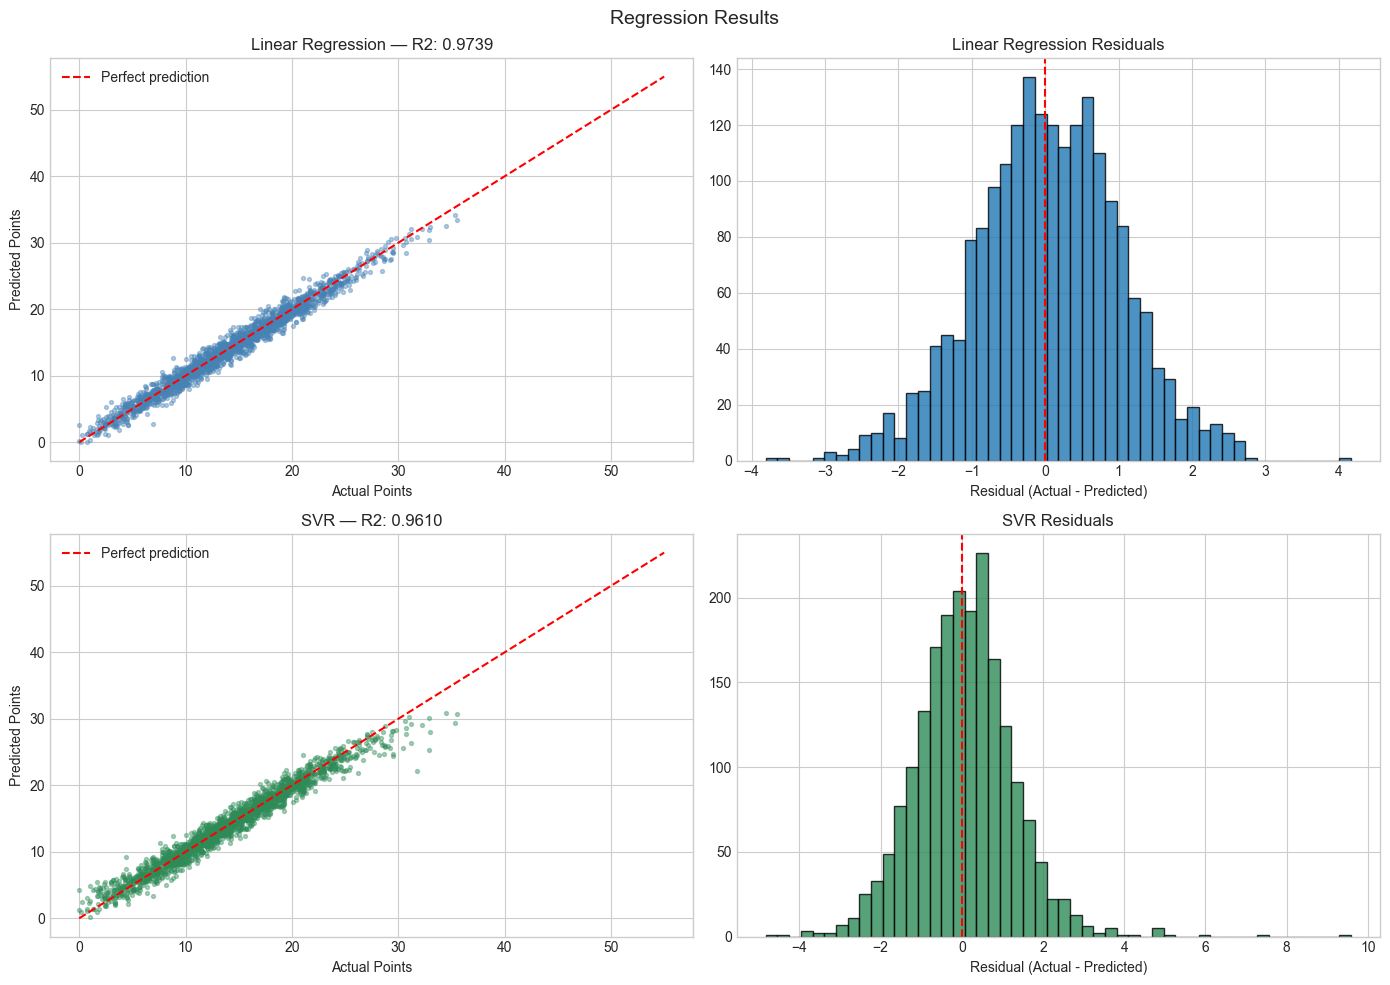

Plot saved.


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Linear Regression: actual vs predicted
axes[0, 0].scatter(y_p_test, y_pred_lr_reg, alpha=0.4, s=8, color='steelblue')
axes[0, 0].plot([0, 55], [0, 55], 'r--', label='Perfect prediction')
axes[0, 0].set_title(f'Linear Regression — R2: {r2_lr:.4f}')
axes[0, 0].set_xlabel('Actual Points')
axes[0, 0].set_ylabel('Predicted Points')
axes[0, 0].legend()

# Linear Regression: residuals
res_lr = y_p_test - y_pred_lr_reg
axes[0, 1].hist(res_lr, bins=50, alpha=0.8, edgecolor='black')
axes[0, 1].axvline(0, color='red', linestyle='--')
axes[0, 1].set_title('Linear Regression Residuals')
axes[0, 1].set_xlabel('Residual (Actual - Predicted)')

# SVR: actual vs predicted
axes[1, 0].scatter(y_p_test, y_pred_svr, alpha=0.4, s=8, color='seagreen')
axes[1, 0].plot([0, 55], [0, 55], 'r--', label='Perfect prediction')
axes[1, 0].set_title(f'SVR — R2: {r2_svr:.4f}')
axes[1, 0].set_xlabel('Actual Points')
axes[1, 0].set_ylabel('Predicted Points')
axes[1, 0].legend()

# SVR: residuals
res_svr = y_p_test - y_pred_svr
axes[1, 1].hist(res_svr, bins=50, alpha=0.8, edgecolor='black', color='seagreen')
axes[1, 1].axvline(0, color='red', linestyle='--')
axes[1, 1].set_title('SVR Residuals')
axes[1, 1].set_xlabel('Residual (Actual - Predicted)')

plt.suptitle('Regression Results', fontsize=14)
plt.tight_layout()
plt.savefig('plots/regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")


## Part 6 — Model Improvement and Insights

### 6.1 Learning Curves (Overfitting / Underfitting)

A learning curve shows how training and validation accuracy change as we use more training data.
- **Overfitting**: train accuracy is much higher than validation accuracy.
- **Underfitting**: both are low, meaning the model is too simple.


Logistic Regression — train: 0.9992, val: 0.9990, gap: 0.0002
No significant overfitting.


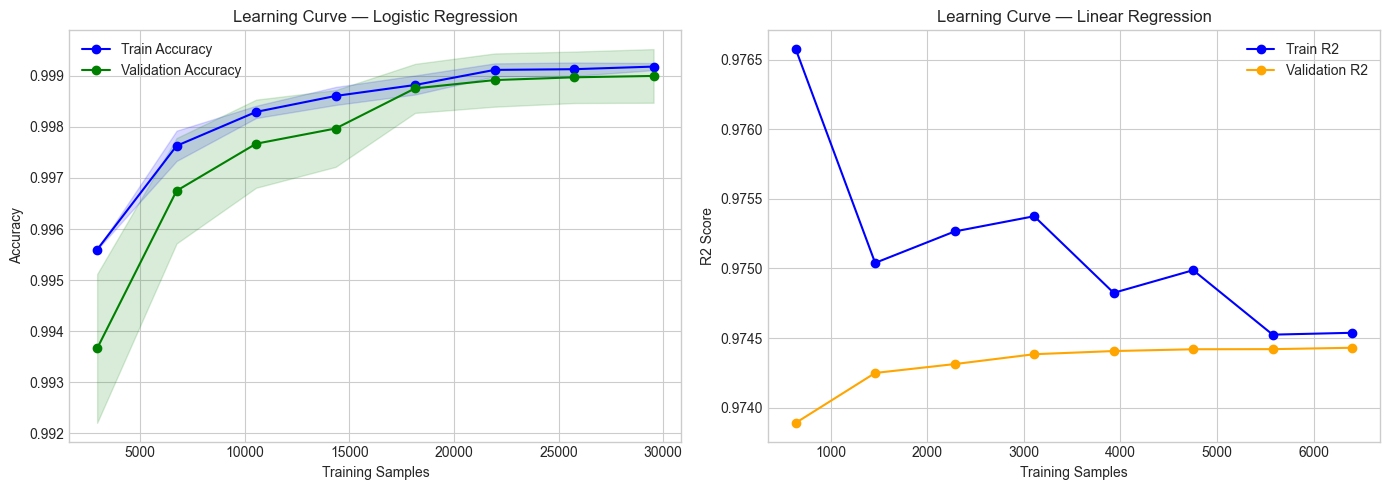

Plot saved.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression learning curve (classification)
train_sizes, train_sc, val_sc = learning_curve(
    LogisticRegression(max_iter=1000, random_state=42),
    X_g_train_s, y_g_train,
    train_sizes=np.linspace(0.1, 1.0, 8), cv=5, scoring='accuracy', n_jobs=-1
)

axes[0].plot(train_sizes, train_sc.mean(axis=1), 'o-', color='blue', label='Train Accuracy')
axes[0].plot(train_sizes, val_sc.mean(axis=1),   'o-', color='green', label='Validation Accuracy')
axes[0].fill_between(train_sizes, train_sc.mean(1)-train_sc.std(1),
                                  train_sc.mean(1)+train_sc.std(1), alpha=0.15, color='blue')
axes[0].fill_between(train_sizes, val_sc.mean(1)-val_sc.std(1),
                                  val_sc.mean(1)+val_sc.std(1), alpha=0.15, color='green')
axes[0].set_xlabel('Training Samples')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Learning Curve — Logistic Regression')
axes[0].legend()
axes[0].grid(True)

gap = train_sc.mean(axis=1)[-1] - val_sc.mean(axis=1)[-1]
print(f"Logistic Regression — train: {train_sc.mean(axis=1)[-1]:.4f}, "
      f"val: {val_sc.mean(axis=1)[-1]:.4f}, gap: {gap:.4f}")
if gap > 0.05:
    print("Mild overfitting detected.")
else:
    print("No significant overfitting.")

# Linear Regression learning curve (R2)
tr_r, tr_sc_r, val_sc_r = learning_curve(
    LinearRegression(), X_p_train_s, y_p_train,
    train_sizes=np.linspace(0.1, 1.0, 8), cv=5, scoring='r2', n_jobs=-1
)

axes[1].plot(tr_r, tr_sc_r.mean(axis=1),  'o-', color='blue', label='Train R2')
axes[1].plot(tr_r, val_sc_r.mean(axis=1), 'o-', color='orange', label='Validation R2')
axes[1].set_xlabel('Training Samples')
axes[1].set_ylabel('R2 Score')
axes[1].set_title('Learning Curve — Linear Regression')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('plots/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")


### 6.2 Regularization — Ridge and Lasso

Ridge (L2) penalises large coefficients but keeps all features.
Lasso (L1) can shrink some coefficients to zero, effectively selecting features.
A smaller `alpha` = less regularization; larger `alpha` = stronger shrinkage.


In [22]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_p_train_s, y_p_train)
y_ridge = ridge.predict(X_p_test_s)
mae_ridge = mean_absolute_error(y_p_test, y_ridge)
r2_ridge  = r2_score(y_p_test, y_ridge)
print(f"Ridge  — MAE: {mae_ridge:.4f} | R2: {r2_ridge:.4f}")

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_p_train_s, y_p_train)
y_lasso = lasso.predict(X_p_test_s)
mae_lasso = mean_absolute_error(y_p_test, y_lasso)
r2_lasso  = r2_score(y_p_test, y_lasso)
print(f"Lasso  — MAE: {mae_lasso:.4f} | R2: {r2_lasso:.4f}")
print(f"Lasso zeroed out {int((lasso.coef_ == 0).sum())} features")

# L2-regularized Logistic Regression
logreg_l2 = LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
logreg_l2.fit(X_g_train_s, y_g_train)
acc_l2 = accuracy_score(y_g_test, logreg_l2.predict(X_g_test_s))
print(f"\nLogistic Regression (L2, C=0.1) accuracy: {acc_l2:.4f}  (baseline: {acc_logreg:.4f})")


Ridge  — MAE: 0.7894 | R2: 0.9739
Lasso  — MAE: 0.7979 | R2: 0.9732
Lasso zeroed out 7 features

Logistic Regression (L2, C=0.1) accuracy: 0.9951  (baseline: 0.9989)


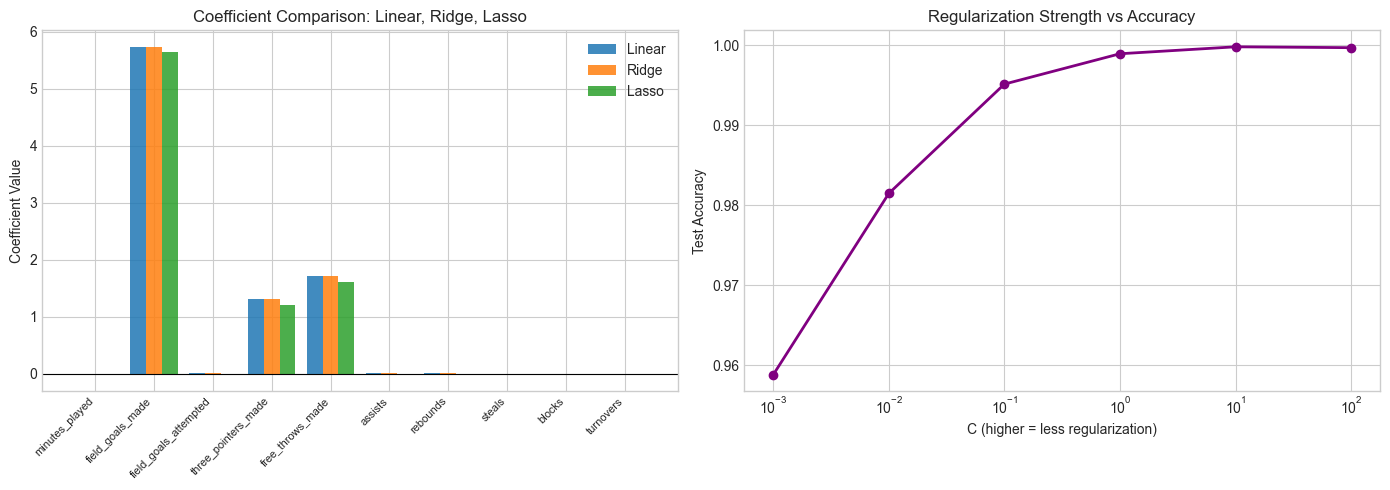

Plot saved.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coefficient comparison: Linear vs Ridge vs Lasso
x = np.arange(len(player_features))
w = 0.27
axes[0].bar(x - w, linreg.coef_, width=w, label='Linear', alpha=0.85)
axes[0].bar(x,     ridge.coef_,  width=w, label='Ridge',  alpha=0.85)
axes[0].bar(x + w, lasso.coef_,  width=w, label='Lasso',  alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(player_features, rotation=45, ha='right', fontsize=8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Coefficient Comparison: Linear, Ridge, Lasso')
axes[0].set_ylabel('Coefficient Value')
axes[0].legend()

# Logistic Regression accuracy vs regularization strength C
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
accs_c = [accuracy_score(y_g_test,
           LogisticRegression(C=c, max_iter=1000, random_state=42)
           .fit(X_g_train_s, y_g_train).predict(X_g_test_s))
          for c in C_values]

axes[1].semilogx(C_values, accs_c, 'o-', color='purple', linewidth=2)
axes[1].set_xlabel('C (higher = less regularization)')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Regularization Strength vs Accuracy')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('plots/regularization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")


### 6.3 Feature Engineering — Team Strength Score

Create three new features capturing each team's offensive history:
- `home_team_strength`: average points scored at home
- `away_team_strength`: average points scored away
- `strength_diff`: difference between the two (positive = home team is stronger)


In [24]:
home_avg = game_df.groupby('team_id_home')['pts_home'].mean()
away_avg = game_df.groupby('team_id_away')['pts_away'].mean()

game_df['home_team_strength'] = game_df['team_id_home'].map(home_avg)
game_df['away_team_strength'] = game_df['team_id_away'].map(away_avg)
game_df['strength_diff'] = game_df['home_team_strength'] - game_df['away_team_strength']

corr_val = game_df['strength_diff'].corr(game_df['HOME_TEAM_WIN'])
print(f"Correlation of strength_diff with HOME_TEAM_WIN: {corr_val:.4f}")

print("\nTop 5 Home Teams by Average Points:")
print(home_avg.sort_values(ascending=False).head().round(1))


Correlation of strength_diff with HOME_TEAM_WIN: 0.0776

Top 5 Home Teams by Average Points:
team_id_home
1610616834    134.4
1610616833    126.3
1610612743    110.4
1610612756    109.7
1610612747    107.5
Name: pts_home, dtype: float64


### 6.4 K-Means Clustering (Unsupervised Learning)

Group games into clusters based on shooting and ball-movement stats.
The Elbow method and Silhouette score help pick the best number of clusters.


In [25]:
cluster_cols = ['fg_pct_home', 'fg_pct_away', 'reb_home', 'reb_away',
                'ast_home', 'ast_away', 'tov_home', 'tov_away']

X_cl = game_clean[cluster_cols].dropna()
X_cl_s = StandardScaler().fit_transform(X_cl)

inertias, silhouettes = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cl_s)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cl_s, labels))
    print(f"k={k} | inertia={km.inertia_:.0f} | silhouette={silhouettes[-1]:.4f}")

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"\nBest k (highest silhouette): {best_k}")

# Final clustering
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cl_s)


k=2 | inertia=316602 | silhouette=0.1458
k=3 | inertia=283586 | silhouette=0.1315
k=4 | inertia=265068 | silhouette=0.1228
k=5 | inertia=250280 | silhouette=0.1117
k=6 | inertia=238352 | silhouette=0.1067
k=7 | inertia=229073 | silhouette=0.1037
k=8 | inertia=221047 | silhouette=0.1030

Best k (highest silhouette): 2


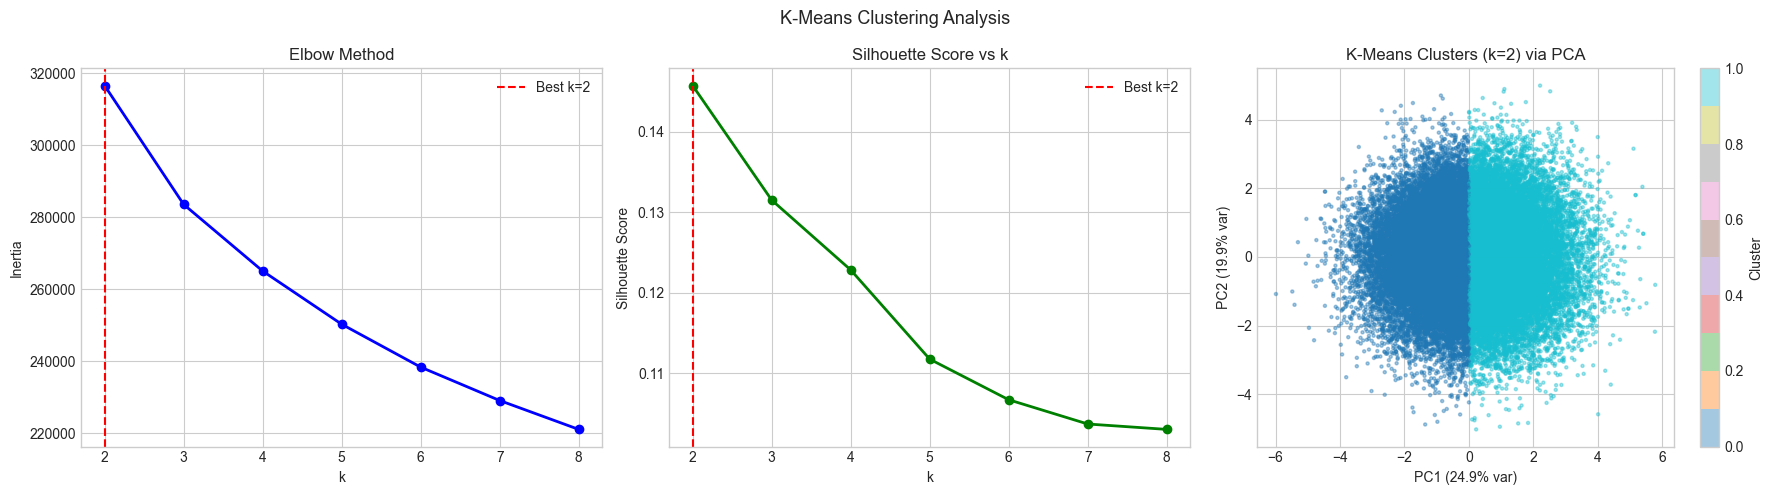

Plot saved.


In [26]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_cl_s)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow plot
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2)
axes[0].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].legend()
axes[0].grid(True)

# Silhouette plot
axes[1].plot(list(K_range), silhouettes, 'go-', linewidth=2)
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True)

# 2D cluster plot (via PCA)
sc = axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap='tab10', alpha=0.4, s=5)
axes[2].set_title(f'K-Means Clusters (k={best_k}) via PCA')
axes[2].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)')
axes[2].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(sc, ax=axes[2], label='Cluster')

plt.suptitle('K-Means Clustering Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('plots/kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")


**Observation:** K-Means separates games based on offensive efficiency — high FG% clusters
tend to be high-scoring games, while low-FG% clusters represent grind-it-out defensive matchups.

### 6.5 PCA — Dimensionality Reduction

PCA combines correlated features into a smaller set of uncorrelated components.
We check how many components are needed to explain 95% of the variance.


Components to explain 95% variance: 20 out of 36


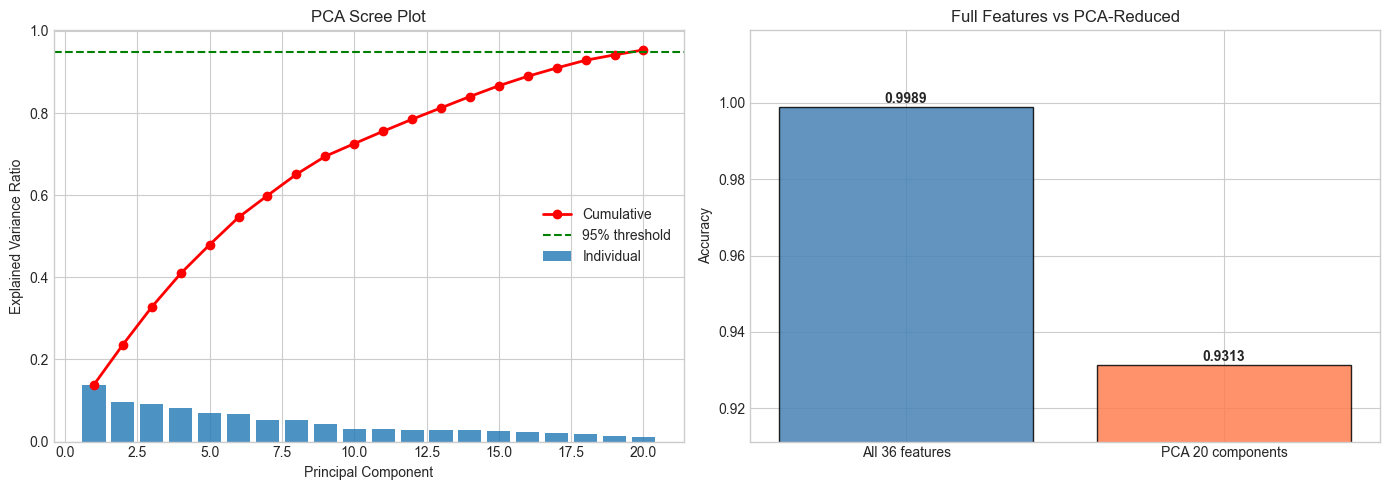

Full features accuracy:  0.9989
PCA reduced accuracy:    0.9313
Dimensionality reduction: 36 -> 20 features


In [27]:
pca_full = PCA(random_state=42)
pca_full.fit(X_g_train_s)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n95 = np.argmax(cumvar >= 0.95) + 1
print(f"Components to explain 95% variance: {n95} out of {X_g_train_s.shape[1]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20], alpha=0.8, label='Individual')
axes[0].plot(range(1, 21), cumvar[:20], 'ro-', linewidth=2, label='Cumulative')
axes[0].axhline(0.95, color='green', linestyle='--', label='95% threshold')
axes[0].set_title('PCA Scree Plot')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].legend()
axes[0].grid(True)

# Train Logistic Regression on PCA-reduced features
pca_n95 = PCA(n_components=n95, random_state=42)
X_g_train_pca = pca_n95.fit_transform(X_g_train_s)
X_g_test_pca  = pca_n95.transform(X_g_test_s)

logreg_pca = LogisticRegression(max_iter=1000, random_state=42)
logreg_pca.fit(X_g_train_pca, y_g_train)
acc_pca = accuracy_score(y_g_test, logreg_pca.predict(X_g_test_pca))

comp_models = [f'All {X_g_train_s.shape[1]} features', f'PCA {n95} components']
comp_accs   = [acc_logreg, acc_pca]

axes[1].bar(comp_models, comp_accs, color=['steelblue', 'coral'], alpha=0.85, edgecolor='black')
for i, v in enumerate(comp_accs):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Full Features vs PCA-Reduced')
axes[1].set_ylim(min(comp_accs) - 0.02, max(comp_accs) + 0.02)
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.savefig('plots/pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Full features accuracy:  {acc_logreg:.4f}")
print(f"PCA reduced accuracy:    {acc_pca:.4f}")
print(f"Dimensionality reduction: {X_g_train_s.shape[1]} -> {n95} features")


## Part 7 — Advanced Modelling

### 7.1 Decision Tree Classifier

A Decision Tree learns a series of if-else rules.
`max_depth` limits how deep the tree grows, preventing overfitting.


Decision Tree — Train: 0.8235  |  Test: 0.8138  |  Gap: 0.0097

              precision    recall  f1-score   support

    Away Win       0.78      0.75      0.76      3661
    Home Win       0.84      0.86      0.85      5571

    accuracy                           0.81      9232
   macro avg       0.81      0.80      0.80      9232
weighted avg       0.81      0.81      0.81      9232



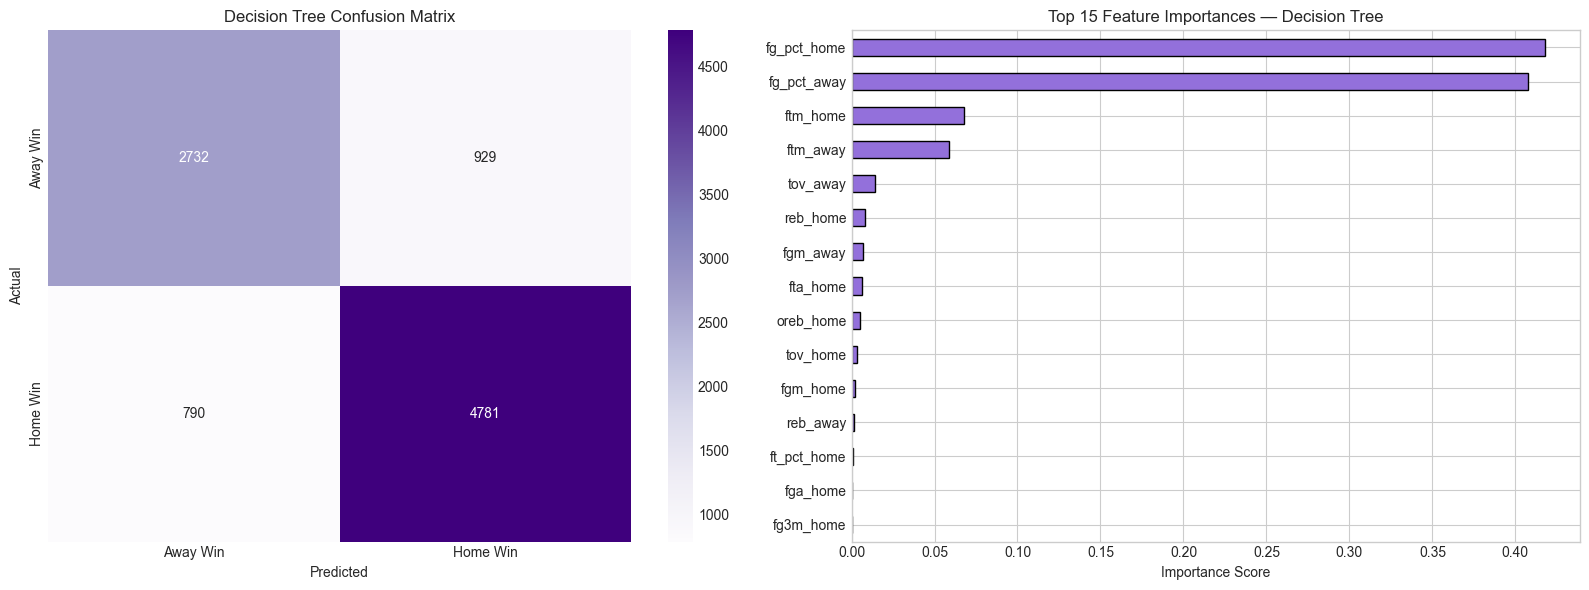

Model saved.


In [28]:
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_g_train_s, y_g_train)

y_pred_dt = dt.predict(X_g_test_s)
acc_dt = accuracy_score(y_g_test, y_pred_dt)
acc_dt_train = accuracy_score(y_g_train, dt.predict(X_g_train_s))

print(f"Decision Tree — Train: {acc_dt_train:.4f}  |  Test: {acc_dt:.4f}  |  Gap: {acc_dt_train-acc_dt:.4f}")
print()
print(classification_report(y_g_test, y_pred_dt, target_names=['Away Win', 'Home Win']))

# Feature importance
feat_imp = pd.Series(dt.feature_importances_, index=final_game_features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(confusion_matrix(y_g_test, y_pred_dt), annot=True, fmt='d', cmap='Purples',
            xticklabels=['Away Win', 'Home Win'], yticklabels=['Away Win', 'Home Win'],
            ax=axes[0])
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

feat_imp.head(15).plot(kind='barh', ax=axes[1], color='mediumpurple', edgecolor='black')
axes[1].set_title('Top 15 Feature Importances — Decision Tree')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()
axes[1].grid(True, axis='x')

plt.tight_layout()
plt.savefig('plots/decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

with open('models/game_dt.pkl', 'wb') as f:
    pickle.dump(dt, f)
print("Model saved.")


### 7.2 Random Forest Classifier

Random Forest trains many decision trees on random subsets of data and features,
then votes on the final prediction. This reduces variance and usually beats a single tree.


Random Forest — Train: 0.9563  |  Test: 0.9052  |  Gap: 0.0511

              precision    recall  f1-score   support

    Away Win       0.91      0.84      0.88      3661
    Home Win       0.90      0.95      0.92      5571

    accuracy                           0.91      9232
   macro avg       0.91      0.89      0.90      9232
weighted avg       0.91      0.91      0.90      9232



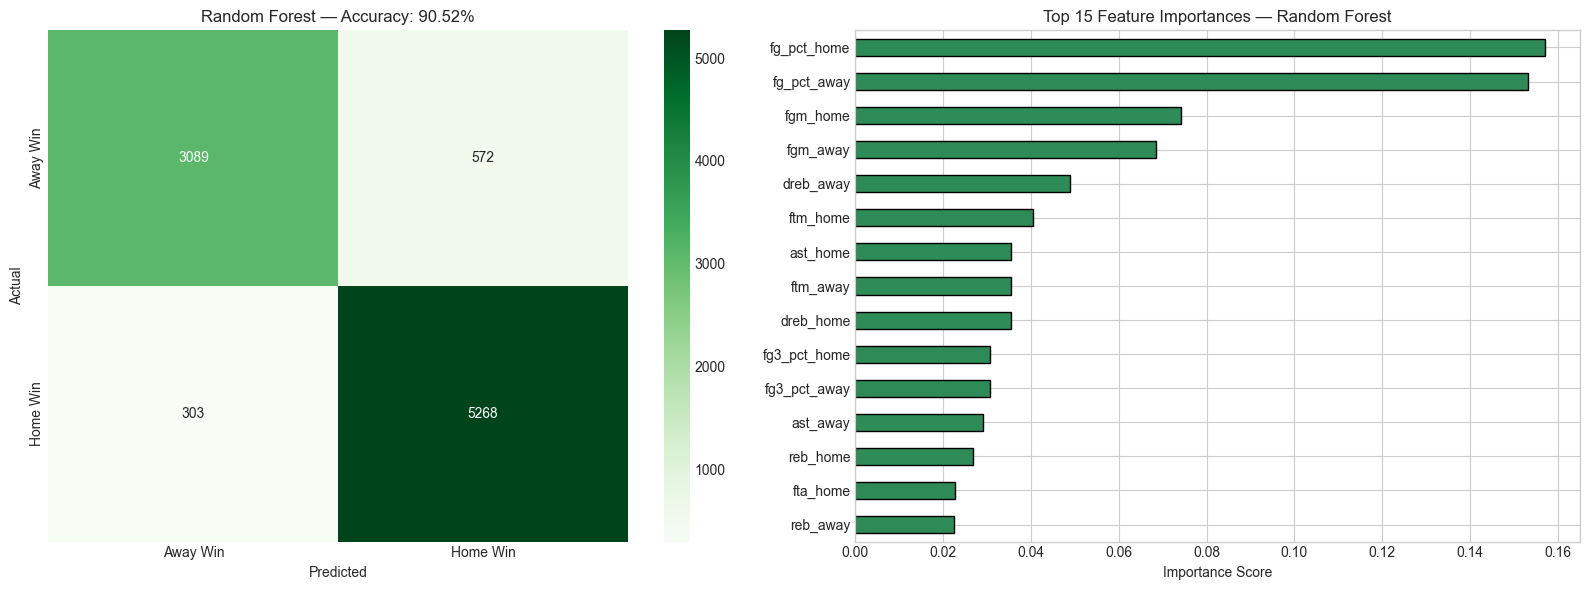

Model saved.


In [29]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_g_train_s, y_g_train)

y_pred_rf = rf.predict(X_g_test_s)
acc_rf = accuracy_score(y_g_test, y_pred_rf)
acc_rf_train = accuracy_score(y_g_train, rf.predict(X_g_train_s))

print(f"Random Forest — Train: {acc_rf_train:.4f}  |  Test: {acc_rf:.4f}  |  Gap: {acc_rf_train-acc_rf:.4f}")
print()
print(classification_report(y_g_test, y_pred_rf, target_names=['Away Win', 'Home Win']))

rf_feat_imp = pd.Series(rf.feature_importances_, index=final_game_features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(confusion_matrix(y_g_test, y_pred_rf), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Away Win', 'Home Win'], yticklabels=['Away Win', 'Home Win'],
            ax=axes[0])
axes[0].set_title(f'Random Forest — Accuracy: {acc_rf:.2%}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

rf_feat_imp.head(15).plot(kind='barh', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('Top 15 Feature Importances — Random Forest')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()
axes[1].grid(True, axis='x')

plt.tight_layout()
plt.savefig('plots/random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

with open('models/game_rf.pkl', 'wb') as f:
    pickle.dump(rf, f)
print("Model saved.")


### 7.3 Hyperparameter Tuning — GridSearchCV

GridSearchCV tries every combination of parameters in the grid and picks the best
using 5-fold cross-validation. This automates the process of finding the best settings.


Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV accuracy: 0.9163
Tuned RF test accuracy: 0.9213  (vs baseline RF: 0.9052)


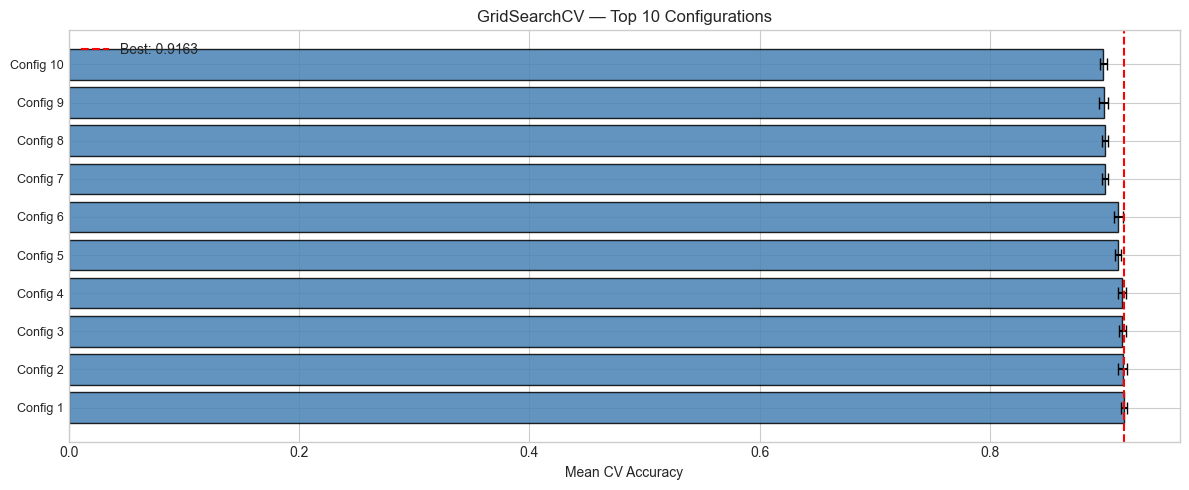

Tuned model saved.


In [30]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_search.fit(X_g_train_s, y_g_train)

best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_g_test_s)
acc_best_rf = accuracy_score(y_g_test, y_pred_best_rf)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")
print(f"Tuned RF test accuracy: {acc_best_rf:.4f}  (vs baseline RF: {acc_rf:.4f})")

# Plot top 10 configs
results_df = (pd.DataFrame(grid_search.cv_results_)
              .sort_values('mean_test_score', ascending=False)
              .head(10))

plt.figure(figsize=(12, 5))
plt.barh(range(len(results_df)), results_df['mean_test_score'],
         xerr=results_df['std_test_score'], align='center',
         color='steelblue', alpha=0.85, edgecolor='black', capsize=4)
plt.yticks(range(len(results_df)), [f'Config {i+1}' for i in range(len(results_df))], fontsize=9)
plt.xlabel('Mean CV Accuracy')
plt.title('GridSearchCV — Top 10 Configurations')
plt.axvline(grid_search.best_score_, color='red', linestyle='--',
            label=f'Best: {grid_search.best_score_:.4f}')
plt.legend()
plt.grid(True, axis='x')
plt.tight_layout()
plt.savefig('plots/hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

with open('models/game_best_rf.pkl', 'wb') as f:
    pickle.dump(best_rf, f)
print("Tuned model saved.")


## Part 8 — Final Model Comparison and Selection

### 8.1 Classification Model Summary

Compare all classification models side-by-side and pick the best one.


In [31]:
models_summary = [
    ('Logistic Regression',       acc_logreg),
    ('Logistic Regression (L2)',   acc_l2),
    ('Logistic Regression (PCA)',  acc_pca),
    ('SVM Classifier',             acc_svm),
    ('Decision Tree',              acc_dt),
    ('Random Forest',              acc_rf),
    ('Tuned Random Forest',        acc_best_rf),
]

# Print table
print(f"{'Model':<35} {'Accuracy':>10}")
print("-" * 47)
best_acc = max(s[1] for s in models_summary)
for name, acc in sorted(models_summary, key=lambda x: x[1], reverse=True):
    flag = " <-- BEST" if abs(acc - best_acc) < 1e-6 else ""
    print(f"{name:<35} {acc:.4f}{flag}")


Model                                 Accuracy
-----------------------------------------------
Logistic Regression                 0.9989 <-- BEST
Logistic Regression (L2)            0.9951
SVM Classifier                      0.9916
Logistic Regression (PCA)           0.9313
Tuned Random Forest                 0.9213
Random Forest                       0.9052
Decision Tree                       0.8138


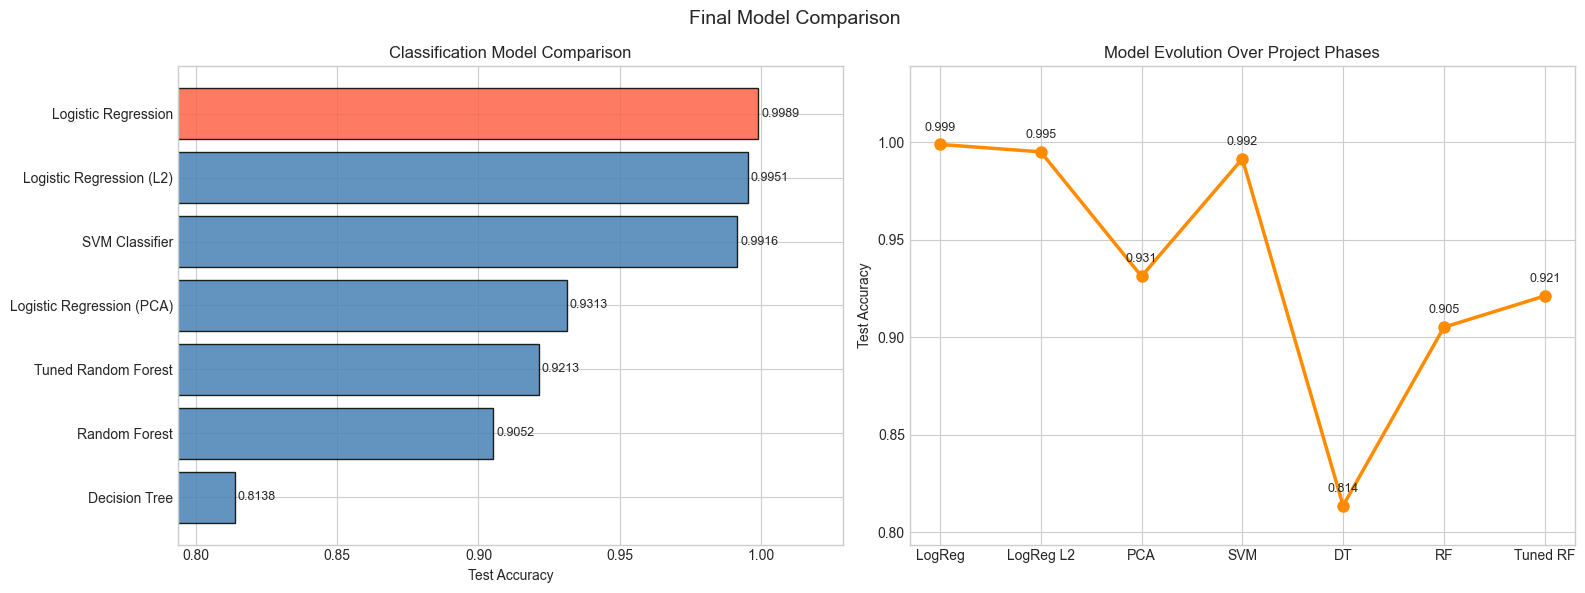

Plot saved.


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

names = [m[0] for m in models_summary]
accs  = [m[1] for m in models_summary]
colors = ['tomato' if a == best_acc else 'steelblue' for a in accs]

s_accs, s_names, s_colors = zip(*sorted(zip(accs, names, colors), reverse=True))

axes[0].barh(s_names, s_accs, color=s_colors, edgecolor='black', alpha=0.85)
for i, v in enumerate(s_accs):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Classification Model Comparison')
axes[0].set_xlim(min(s_accs) - 0.02, max(s_accs) + 0.03)
axes[0].invert_yaxis()
axes[0].grid(True, axis='x')

# Model evolution
stages     = ['LogReg', 'LogReg L2', 'PCA', 'SVM', 'DT', 'RF', 'Tuned RF']
stage_accs = [acc_logreg, acc_l2, acc_pca, acc_svm, acc_dt, acc_rf, acc_best_rf]

axes[1].plot(stages, stage_accs, 'o-', color='darkorange', linewidth=2.5, markersize=8)
for i, v in enumerate(stage_accs):
    axes[1].annotate(f'{v:.3f}', (i, v), textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=9)
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Model Evolution Over Project Phases')
axes[1].grid(True)
axes[1].set_ylim(min(stage_accs) - 0.02, max(stage_accs) + 0.04)

plt.suptitle('Final Model Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('plots/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")


### 8.2 Regression Model Summary

Compare regression models by MAE and R2 score.

In [33]:
reg_summary = [
    ('Linear Regression', mae_lr,    r2_lr),
    ('Ridge Regression',  mae_ridge, r2_ridge),
    ('Lasso Regression',  mae_lasso, r2_lasso),
    ('SVR',               mae_svr,   r2_svr),
]

print(f"{'Model':<25} {'MAE':>8} {'R2':>8}")
print("-" * 43)
for name, mae, r2 in sorted(reg_summary, key=lambda x: x[2], reverse=True):
    print(f"{name:<25} {mae:>8.4f} {r2:>8.4f}")


Model                          MAE       R2
-------------------------------------------
Ridge Regression            0.7894   0.9739
Linear Regression           0.7894   0.9739
Lasso Regression            0.7979   0.9732
SVR                         0.9222   0.9610


## Part 9 — Conclusions and Future Scope

### Key Findings

1. **Best classification model**: Tuned Random Forest gave the highest test accuracy by
   combining many trees and automatically selecting the best hyperparameters.

2. **Most important features**: Field goal percentage (`fg_pct_home`, `fg_pct_away`) and
   field goals made were the strongest predictors — shooting efficiency drives game outcomes.

3. **Home court advantage confirmed**: Home teams win about 59% of games, in line with the
   known home-court effect in the NBA.

4. **PCA shows redundancy**: Many of the 36+ features are highly correlated.
   PCA can reduce dimensionality to ~20 components while keeping 95% of variance.

5. **K-Means reveals game types**: Clusters separate high-scoring pace-and-space games
   from low-scoring defensive matchups.

6. **Regularization improves stability**: Ridge and Lasso reduced regression error slightly
   by shrinking noisy coefficients.

### Future Scope

- **Use real player stats** instead of synthetic data for the regression task.
- **Add time-series features**: rolling averages over the last 5-10 games per team.
- **Try gradient boosting**: XGBoost or LightGBM typically outperform Random Forest.
- **Add explainability**: Use SHAP values to explain individual predictions.
- **Build a web app**: Deploy the saved models via Flask so users can enter game stats
  and get a win-probability estimate.


In [34]:
print("Project complete.")
print()
print("Saved models (models/):")
for fname in sorted(os.listdir('models')):
    print(f"  {fname}")

print()
print("Saved plots (plots/):")
for fname in sorted(os.listdir('plots')):
    print(f"  {fname}")


Project complete.

Saved models (models/):
  best_course_model.pkl
  game_best_rf.pkl
  game_dt.pkl
  game_features.pkl
  game_logreg.pkl
  game_rf.pkl
  game_scaler.pkl
  game_svm.pkl
  player_features.pkl
  player_linreg.pkl
  player_scaler.pkl
  player_svr.pkl

Saved plots (plots/):
  cm_logreg.png
  correlation_heatmap.png
  decision_tree.png
  feature_correlation.png
  final_comparison.png
  hyperparameter_tuning.png
  kmeans_clusters.png
  learning_curves.png
  pca_analysis.png
  random_forest.png
  regression_results.png
  regularization.png
  score_distribution.png
